In [81]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

In [82]:
# Datensatz laden
df = sns.load_dataset('titanic')

# Auswahl einfacher Features
df = df[['survived', 'pclass', 'sex', 'age', 'fare']]

print("vor", df.shape)
# Fehlende Werte entfernen
df.dropna(inplace=True)
print("nach", df.shape)

# Kategorie umwandeln (female=0, male=1)
df['sex'] = pd.get_dummies(df['sex'], drop_first=True)
df['age_squared'] = df['age']**2

vor (891, 5)
nach (714, 5)


In [83]:
# Aufteilen
X = df[['pclass', 'sex', 'age', 'fare']] # 'age_squared'
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("x_train", X_train.shape)
print("x_test", X_test.shape)

x_train (571, 4)
x_test (143, 4)


              precision    recall  f1-score   support

           0       0.81      0.78      0.80        87
           1       0.68      0.71      0.70        56

    accuracy                           0.76       143
   macro avg       0.74      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143

[[68 19]
 [16 40]]
Features: ['pclass', 'sex', 'age', 'fare']
Koeffizienten: [-1.2408174500182862, -2.530362068274475, -0.04245683654180309, 0.00022727615164158565]
Eingabewerte für die ersten 5 Datensätze + berechnete Wahrscheinlichkeiten für Überleben (Klasse 1)
     pclass    sex   age   fare
149       2   True  42.0  13.00
407       2   True   3.0  18.75
53        2  False  29.0  26.00
369       1  False  24.0  69.30
818       3   True  43.0   6.45
Wahrscheinlichkeiten
[0.16105105 0.50167374 0.80765231 0.94773608 0.05044109]


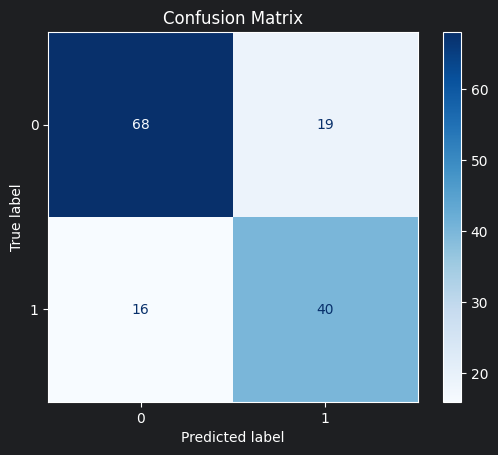

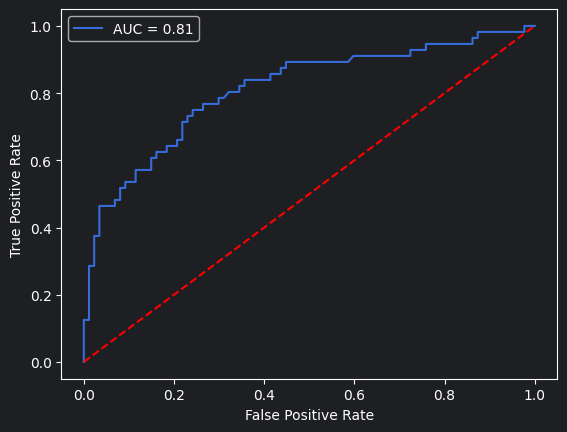

In [84]:
# Modell
model = LogisticRegression()
model.fit(X_train, y_train)

# Vorhersagen
predictions = model.predict(X_test)

# Auswertung
print(classification_report(y_test, predictions))
cm = confusion_matrix(y_test, predictions)
print(cm)

# Koeffizienten ausgeben
print("Features:", X.columns.tolist())
print("Koeffizienten:", model.coef_[0].tolist())

# Confusion Matrix plotten
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.savefig("cm.png")
#plt.show()

# Wahrscheinlichkeiten
probs = model.predict_proba(X_test)[:,1]
print("Eingabewerte für die ersten 5 Datensätze + berechnete Wahrscheinlichkeiten für Überleben (Klasse 1)")
print(X_test[:5])
print("Wahrscheinlichkeiten")
print(probs[:5])

# ROC-Kurve
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("roc_curve.png")
#plt.show()

In [85]:
ds = X.copy()
ds["prob"] = model.predict_proba(ds)[:,1]
ds

,pclass,sex,age,fare,prob
0,3,True,22.0,7.2500,0.114719
1,1,False,38.0,71.2833,0.909193
2,3,False,26.0,7.9250,0.578659
3,1,False,35.0,53.1000,0.918868
4,3,True,35.0,8.0500,0.069450
...,...,...,...,...,...
885,3,False,39.0,29.1250,0.442790
886,2,True,27.0,13.0000,0.266281
887,1,False,19.0,30.0000,0.956939
889,1,True,26.0,30.0000,0.567967
